# Feature Engineering on Titanic Dataset

## Import Required Libraries

In [1]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA


## Load the Dataset

In [2]:

df = sns.load_dataset('titanic')
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Dataset Overview

In [3]:

df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## Separate Numerical and Categorical Columns

In [4]:

num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(list(num_cols))

print("\nCategorical Columns:")
print(list(cat_cols))

print("\nTotal Numerical Columns:", len(num_cols))
print("Total Categorical Columns:", len(cat_cols))

Numerical Columns:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']

Categorical Columns:
['sex', 'embarked', 'who', 'embark_town', 'alive']

Total Numerical Columns: 6
Total Categorical Columns: 5


## Handle Missing Values

In [5]:
print("Missing values before handling:")
print(df.isnull().sum())

num_imputer = SimpleImputer(strategy='mean')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print("\nMissing values after handling:")
print(df.isnull().sum())


Missing values before handling:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Missing values after handling:
survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      0
alive            0
alone            0
dtype: int64


## Handle Categorical Values

In [6]:
from sklearn.preprocessing import LabelEncoder

print("Categorical columns before handling:")
print(cat_cols)

label_encoder = LabelEncoder()

for col in cat_cols:
    df[col] = label_encoder.fit_transform(df[col])

print("\nCategorical columns after handling:")
print(df[cat_cols].head())


Categorical columns before handling:
Index(['sex', 'embarked', 'who', 'embark_town', 'alive'], dtype='object')

Categorical columns after handling:
   sex  embarked  who  embark_town  alive
0    1         2    1            2      0
1    0         0    2            0      1
2    0         2    2            2      1
3    0         2    2            2      1
4    1         2    1            2      0


## Separate Features and Target Variable

In [7]:
X = df.drop('survived', axis=1)
y = df['survived']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (891, 14)
Shape of y: (891,)


## Update Numerical Columns After Feature Separation


In [8]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

print("Updated numerical columns:")
print(list(num_cols))


Updated numerical columns:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'who', 'embark_town', 'alive']


## Remove Outliers

In [9]:
Q1 = X[num_cols].quantile(0.25)
Q3 = X[num_cols].quantile(0.75)
IQR = Q3 - Q1

print("Shape before removing outliers:", X.shape)

X = X[~((X[num_cols] < (Q1 - 1.5 * IQR)) | 
        (X[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

y = y.loc[X.index]

print("Shape after removing outliers:", X.shape)


Shape before removing outliers: (891, 14)


Shape after removing outliers: (577, 14)


## Feature Scaling

In [10]:
from sklearn.preprocessing import StandardScaler

num_cols = X.select_dtypes(include=['int64','float64']).columns

print("Before scaling:")
print(X[num_cols].describe())

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

print("\nAfter scaling:")
print(X[num_cols].describe())


Before scaling:
           pclass         sex         age       sibsp  parch        fare  \
count  577.000000  577.000000  577.000000  577.000000  577.0  577.000000   
mean     2.502600    0.752166   29.742060    0.199307    0.0   14.926356   
std      0.733909    0.432129    8.516997    0.445034    0.0   12.606521   
min      1.000000    0.000000    5.000000    0.000000    0.0    0.000000   
25%      2.000000    1.000000   24.000000    0.000000    0.0    7.775000   
50%      3.000000    1.000000   29.699118    0.000000    0.0    8.662500   
75%      3.000000    1.000000   32.500000    0.000000    0.0   15.850000   
max      3.000000    1.000000   54.000000    2.000000    0.0   61.175000   

         embarked         who  embark_town       alive  
count  577.000000  577.000000   577.000000  577.000000  
mean     1.611785    1.213172     1.611785    0.299827  
std      0.718119    0.454109     0.718119    0.458579  
min      0.000000    0.000000     0.000000    0.000000  
25%      2.000

## Ensure All Features Are Numeric


In [11]:
print("Data types before fixing:")
print(X.dtypes)

X = pd.get_dummies(X, drop_first=True)

print("\nData types after fixing:")
print(X.dtypes)
print("\nNew shape of X:", X.shape)


Data types before fixing:
pclass          float64
sex             float64
age             float64
sibsp           float64
parch           float64
fare            float64
embarked        float64
class          category
who             float64
adult_male         bool
deck           category
embark_town     float64
alive           float64
alone              bool
dtype: object

Data types after fixing:
pclass          float64
sex             float64
age             float64
sibsp           float64
parch           float64
fare            float64
embarked        float64
who             float64
adult_male         bool
embark_town     float64
alive           float64
alone              bool
class_Second       bool
class_Third        bool
deck_B             bool
deck_C             bool
deck_D             bool
deck_E             bool
deck_F             bool
deck_G             bool
dtype: object

New shape of X: (577, 20)


## Feature Selection

In [12]:
from sklearn.feature_selection import VarianceThreshold

print("Features before selection:", X.shape[1])

selector = VarianceThreshold(threshold=0.01)
X_selected = selector.fit_transform(X)

print("Features after selection:", X_selected.shape[1])


Features before selection: 20
Features after selection: 18


## Principal Component Analysis (PCA)

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_selected)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)


Explained variance ratio:
[0.27500303 0.21108408]


## PCA Visualization

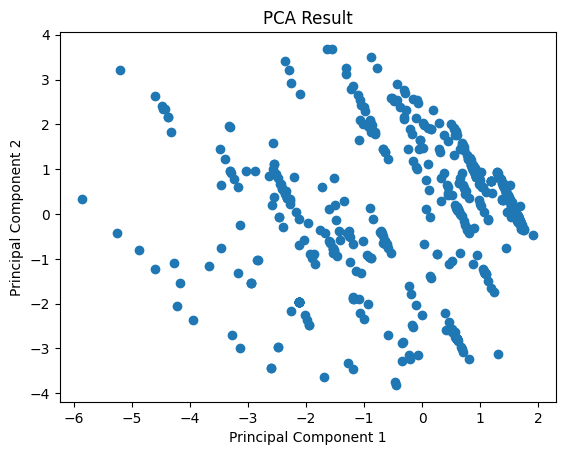

In [14]:
import matplotlib.pyplot as plt

plt.scatter(X_pca[:,0], X_pca[:,1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Result")
plt.show()


## Conclusion

In this assignment, different feature engineering techniques were applied to the Titanic dataset. Missing values were handled, categorical data was converted into numerical form, features were scaled, and outliers were removed. Feature selection and PCA were also performed to reduce dimensionality. These steps helped in preparing the dataset for further machine learning tasks.